## 0) Setup & Configuration

In [1]:
"""
This notebook configures and runs an LSTM-based individual identification experiment
using BirdNET embeddings extracted from segmented audio files. The current setup is
tailored to the great tit dataset and supports only the across-year evaluation setting.

Main functionalities
- Sets a global random seed for reproducibility using Lightning.
- Defines experiment, input, and output paths relative to the project root.
- Supports sequence-level experiments with either ordered or shuffled embedding sequences.
- Supports two split modes:
    1) fixed_original: uses the original train/val/test CSV files.
    2) random_seeded: will later allow rebuilding train/val/test partitions using SEED.
- Configures logging, metrics, classification reports, and figure output directories.
- Specifies model hyperparameters for the BirdNET + LSTM pipeline.

Key configuration variables
- SEED: Random seed used for reproducibility in splitting, shuffling, and training.
- DATASET_NAME: Dataset name. Here it is set to "greatTit".
- SPLIT_TYPE: Evaluation subset. For this dataset, only "acrossyear" is supported.
- SEQUENCE: Sequence mode for the embeddings, either "ordered" or "shuffled".
- SPLIT_MODE: Split strategy, either "fixed_original" or "random_seeded".
- EXPERIMENT_TAG: Descriptive tag used to name the current experiment.
- PARENT_DIR: Project root directory used to build all relative paths.

Input paths
- PARTS_DIR: Directory containing Parquet parts with BirdNET embeddings.
- METADATA_DIR: Directory containing the original train/val/test metadata CSVs.
- TRN_CSV: Metadata CSV for the training split.
- VAL_CSV: Metadata CSV for the validation split.
- TST_CSV: Metadata CSV for the test split.

Data columns
- LABEL_KEY_COL: Filename column used in the metadata CSVs.
- EMB_KEY_COL: Filename column used in the embedding Parquet files.
- LIMIT_N_PARTS: Optional limit on the number of embedding parts to load. Use 0 to load all.

Output paths
- LOG_ROOT: Base directory for Lightning logs.
- LOG_DIR: Directory where experiment logs are stored.
- RUN_NAME: Unique name for the current run, built from dataset, split, sequence, and split mode.
- RESULTS_DIR: Base output directory for experiment results.
- METRICS_DIR: Directory where aggregated metrics files are saved.
- METRICS_FILE: CSV file used to store or update run-level metrics.
- CLASS_REPORT_TXT_FILE: Text file with the per-class classification report.
- CLASS_REPORT_CSV_FILE: CSV file with per-class precision, recall, F1-score, and support.
- FIGURES_DIR: Directory where result figures are saved.

Model hyperparameters
- EMBEDDING_DIM: Dimensionality of BirdNET embeddings.
- HIDDEN_DIM: Hidden dimension of the LSTM.
- LEARNING_RATE: Learning rate used by the optimizer.

Notes
- This notebook supports only the across-year great tit setting.
- In shuffled mode, the temporal order of embeddings is destroyed while preserving
  the same embeddings and sequence lengths.
- Ensure that all input directories and metadata files exist before running the notebook.
"""

from lightning import seed_everything

SEED = 46
seed_everything(SEED, workers=True)

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# ---- Dataset config ----
DATASET_NAME = "greatTit"
SPLIT_TYPE = "acrossyear"          # only "acrossyear" is supported
SEQUENCE = "ordered"              # options: "ordered", "shuffled"
SPLIT_MODE = "random_seeded"      # options: "fixed_original", "random_seeded"

EXPERIMENT_TAG = f"birdnet_lstm_{SEQUENCE}_{SPLIT_MODE}"
PARENT_DIR = Path.cwd().parent

# ---- Input paths ----
PARTS_DIR = (
    PARENT_DIR
    / "Output_files"
    / "Embeddings_from_3sPadding"
    / f"{DATASET_NAME}_parquet_parts"
)

METADATA_DIR = PARENT_DIR / "Output_metadata" / "GreatTit_metadata"

if SPLIT_TYPE == "withinyear":
    raise ValueError(
        f"Dataset '{DATASET_NAME}' does not support split '{SPLIT_TYPE}'. "
        "Set SPLIT_TYPE to 'acrossyear'."
    )
elif SPLIT_TYPE == "acrossyear":
    TRN_CSV = METADATA_DIR / "train_metadata.csv"
    VAL_CSV = METADATA_DIR / "val_metadata.csv"
    TST_CSV = METADATA_DIR / "test_metadata.csv"
else:
    raise ValueError(f"Unknown split type: {SPLIT_TYPE}")

# ---- Data columns ----
LABEL_KEY_COL = "filename"
EMB_KEY_COL = "file_name"

# Optional quick subset of parts (0 = use all)
LIMIT_N_PARTS = 0

# ---- Output paths ----
LOG_ROOT = PARENT_DIR / "logs"
RUN_NAME = f"{DATASET_NAME}_{SPLIT_TYPE}_{EXPERIMENT_TAG}"
LOG_DIR = LOG_ROOT / DATASET_NAME / SPLIT_TYPE
LOG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = PARENT_DIR / "Results" / DATASET_NAME / SPLIT_TYPE
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_DIR = RESULTS_DIR / "Metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = METRICS_DIR / f"{RUN_NAME}_final_metrics.csv"
CLASS_REPORT_TXT_FILE = METRICS_DIR / f"{RUN_NAME}_test_classification_report.txt"
CLASS_REPORT_CSV_FILE = METRICS_DIR / f"{RUN_NAME}_test_classification_report.csv"

AGGREGATE_METRICS_FILE = METRICS_DIR / f"{RUN_NAME}_aggregate_summary.csv"
AGGREGATE_PRETTY_FILE = METRICS_DIR / f"{RUN_NAME}_aggregate_summary_pretty.csv"

FIGURES_DIR = RESULTS_DIR / f"{RUN_NAME}_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_NAME:", DATASET_NAME)
print("SPLIT_TYPE:", SPLIT_TYPE)
print("SEQUENCE:", SEQUENCE)
print("SPLIT_MODE:", SPLIT_MODE)
print("PARTS_DIR:", PARTS_DIR)
print("TRN_CSV:", TRN_CSV)
print("VAL_CSV:", VAL_CSV)
print("TST_CSV:", TST_CSV)
print("LOG_DIR:", LOG_DIR / RUN_NAME)
print("METRICS_FILE:", METRICS_FILE)
print("FIGURES_DIR:", FIGURES_DIR)

# ---- Model hyperparameters ----
EMBEDDING_DIM = 1024
HIDDEN_DIM = 256
LEARNING_RATE = 1e-3

Seed set to 46


DATASET_NAME: greatTit
SPLIT_TYPE: acrossyear
SEQUENCE: ordered
SPLIT_MODE: random_seeded
PARTS_DIR: /teamspace/studios/this_studio/Output_files/Embeddings_from_3sPadding/greatTit_parquet_parts
TRN_CSV: /teamspace/studios/this_studio/Output_metadata/GreatTit_metadata/train_metadata.csv
VAL_CSV: /teamspace/studios/this_studio/Output_metadata/GreatTit_metadata/val_metadata.csv
TST_CSV: /teamspace/studios/this_studio/Output_metadata/GreatTit_metadata/test_metadata.csv
LOG_DIR: /teamspace/studios/this_studio/logs/greatTit/acrossyear/greatTit_acrossyear_birdnet_lstm_ordered_random_seeded
METRICS_FILE: /teamspace/studios/this_studio/Results/greatTit/acrossyear/Metrics/greatTit_acrossyear_birdnet_lstm_ordered_random_seeded_final_metrics.csv
FIGURES_DIR: /teamspace/studios/this_studio/Results/greatTit/acrossyear/greatTit_acrossyear_birdnet_lstm_ordered_random_seeded_figures


## 1) Load and combine labels (one-hot → single label per file)

In [2]:
from pathlib import Path
import pandas as pd

def _load_with_split(path: Path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str, keep_default_na=False)

    if LABEL_KEY_COL not in df.columns:
        raise ValueError(f"Missing filename column '{LABEL_KEY_COL}' in {path}.")

    # Normalize filename key for matching against embedding parquet rows
    df[LABEL_KEY_COL] = df[LABEL_KEY_COL].astype(str).str.strip().str.lower()

    # Keep the original split assignment from the metadata files
    df["source_split"] = split_name
    return df


csv_chunks = []

if "TRN_CSV" in locals() and TRN_CSV is not None and Path(TRN_CSV).exists():
    csv_chunks.append(_load_with_split(Path(TRN_CSV), "train"))

if "VAL_CSV" in locals() and VAL_CSV is not None and Path(VAL_CSV).exists():
    csv_chunks.append(_load_with_split(Path(VAL_CSV), "val"))

if "TST_CSV" in locals() and TST_CSV is not None and Path(TST_CSV).exists():
    csv_chunks.append(_load_with_split(Path(TST_CSV), "test"))

if not csv_chunks:
    raise ValueError(
        "No metadata CSVs found. Provide at least TRN_CSV "
        "(and optionally VAL_CSV/TST_CSV)."
    )

combined_df = pd.concat(csv_chunks, ignore_index=True)

# ------------------------------------------------------------------
# Build a unified label column
# ------------------------------------------------------------------
SINGLE_LABEL_COLS = [
    c for c in ["father", "class", "label", "individual_id"]
    if c in combined_df.columns
]

if SINGLE_LABEL_COLS:
    LABEL_VALUE_COL = SINGLE_LABEL_COLS[0]
    combined_df["label"] = combined_df[LABEL_VALUE_COL].astype(str).str.strip()
    print(f"[Single-label schema] Using '{LABEL_VALUE_COL}' as labels.")
else:
    non_label_cols = {LABEL_KEY_COL, "source_split"}
    indiv_cols = [c for c in combined_df.columns if c not in non_label_cols]

    if not indiv_cols:
        raise ValueError("No one-hot individual columns found in the metadata CSVs.")

    one_hot_block = combined_df[indiv_cols].astype(float)
    row_sums = one_hot_block.sum(axis=1)

    if (row_sums == 0).all():
        raise ValueError(
            "All rows in the one-hot block are zeros; no labeled files detected."
        )

    combined_df["label"] = one_hot_block.idxmax(axis=1)
    print(f"[One-hot schema] Derived labels from one-hot columns (n={len(indiv_cols)}).")

# ------------------------------------------------------------------
# Build filename -> label mapping
# ------------------------------------------------------------------
label_conflicts = (
    combined_df[[LABEL_KEY_COL, "label"]]
    .drop_duplicates()
    .groupby(LABEL_KEY_COL)["label"]
    .nunique()
)

conflicting_labels = label_conflicts[label_conflicts > 1]
if not conflicting_labels.empty:
    raise ValueError(
        f"Found {len(conflicting_labels)} filenames with conflicting labels across metadata files."
    )

combined_labels_dict = (
    combined_df[[LABEL_KEY_COL, "label"]]
    .drop_duplicates(subset=[LABEL_KEY_COL])
    .set_index(LABEL_KEY_COL)["label"]
    .to_dict()
)

# ------------------------------------------------------------------
# Build filename -> original split mapping
# This is useful for SPLIT_MODE == 'fixed_original'
# ------------------------------------------------------------------
source_split_series = (
    combined_df.drop_duplicates([LABEL_KEY_COL, "source_split"])
    .groupby(LABEL_KEY_COL)["source_split"]
    .agg(list)
)

split_conflicts = {k: v for k, v in source_split_series.items() if len(v) > 1}
if split_conflicts:
    print(
        f"⚠️ {len(split_conflicts)} filenames appear in multiple original splits. "
        "Keeping the first occurrence by priority (train > val > test)."
    )

priority = {"train": 0, "val": 1, "test": 2}

def _pick_first_split(splits):
    return sorted(splits, key=lambda x: priority.get(x, 99))[0]

source_split_by_file = {
    k: _pick_first_split(v) for k, v in source_split_series.items()
}

label_keys = set(combined_labels_dict.keys())

print(f"Loaded {len(combined_df):,} metadata rows.")
print(f"Unique labeled audio files: {len(label_keys):,}")
print(f"Original split mode available: {sorted(set(combined_df['source_split']))}")
print("Example label mapping:", list(combined_labels_dict.items())[:3])

if SPLIT_MODE == "fixed_original":
    print("SPLIT_MODE = fixed_original -> downstream code should use source_split_by_file.")
elif SPLIT_MODE == "random_seeded":
    print("SPLIT_MODE = random_seeded -> downstream code should ignore source_split_by_file and rebuild splits with SEED.")
else:
    raise ValueError(
        f"Unknown SPLIT_MODE: {SPLIT_MODE}. "
        "Use 'fixed_original' or 'random_seeded'."
    )

[Single-label schema] Using 'father' as labels.
Loaded 74,048 metadata rows.
Unique labeled audio files: 74,048
Original split mode available: ['test', 'train', 'val']
Example label mapping: [('20221o78_20220420_050000_41810944.wav', 'pf71344'), ('20221o78_20220420_040000_123724160.wav', 'pf71344'), ('20221o78_20220420_040000_127732608.wav', 'pf71344')]
SPLIT_MODE = random_seeded -> downstream code should ignore source_split_by_file and rebuild splits with SEED.


## 2) Read embeddings from Parquet parts and keep only labeled files

This loads one part at a time to keep memory usage reasonable.

In [3]:
# Find Parquet parts
parts = sorted(PARTS_DIR.glob("part_*.parquet"))
if LIMIT_N_PARTS > 0:
    parts = parts[:LIMIT_N_PARTS]

if not parts:
    raise FileNotFoundError(f"No parquet parts found in: {PARTS_DIR}")

print(f"Found {len(parts)} parquet parts; first 3:", [p.name for p in parts[:3]])

# ------------------------------------------------------------------
# Build a single DataFrame of labeled embeddings
# Each kept row will have:
# - EMB_KEY_COL
# - embedding dimensions / metadata already present in parquet
# - label
# - source_split (from original metadata CSVs)
# ------------------------------------------------------------------
kept_chunks = []
total_rows_read = 0
total_rows_kept = 0

for part in parts:
    df_part = pd.read_parquet(part)
    total_rows_read += len(df_part)

    # Normalize filename column for matching
    if EMB_KEY_COL not in df_part.columns:
        raise ValueError(f"Parquet part {part.name} is missing column '{EMB_KEY_COL}'")

    df_part[EMB_KEY_COL] = df_part[EMB_KEY_COL].astype(str).str.strip().str.lower()

    # Keep only rows whose file appears in the metadata
    df_part = df_part[df_part[EMB_KEY_COL].isin(label_keys)].copy()
    if df_part.empty:
        continue

    # Drop 'path' if present
    if "path" in df_part.columns:
        df_part = df_part.drop(columns=["path"])

    # Attach label and original split at the file level
    df_part["label"] = df_part[EMB_KEY_COL].map(combined_labels_dict)
    df_part["source_split"] = df_part[EMB_KEY_COL].map(source_split_by_file)

    # Safety checks
    if df_part["label"].isna().any():
        missing = df_part.loc[df_part["label"].isna(), EMB_KEY_COL].unique()[:5]
        raise ValueError(
            f"Missing labels for some embedding rows after mapping. Examples: {missing}"
        )

    if df_part["source_split"].isna().any():
        missing = df_part.loc[df_part["source_split"].isna(), EMB_KEY_COL].unique()[:5]
        raise ValueError(
            f"Missing source_split for some embedding rows after mapping. Examples: {missing}"
        )

    total_rows_kept += len(df_part)
    kept_chunks.append(df_part)

# Concatenate all kept rows
if kept_chunks:
    trainvaltest_df = pd.concat(kept_chunks, ignore_index=True)
else:
    raise ValueError(
        "No embedding rows matched the labeled filenames from the metadata CSVs."
    )

# Optional: keep split order consistent for inspection
split_order = pd.CategoricalDtype(categories=["train", "val", "test"], ordered=True)
trainvaltest_df["source_split"] = trainvaltest_df["source_split"].astype(split_order)

print(f"Total parquet rows read: {total_rows_read:,}")
print(f"Total kept rows after filtering by labels: {total_rows_kept:,}")
print(f"Unique kept audio files: {trainvaltest_df[EMB_KEY_COL].nunique():,}")
print("Rows per original split:")
print(trainvaltest_df["source_split"].value_counts(dropna=False).sort_index())
print("Missing labels:", trainvaltest_df["label"].isna().sum())
print("Missing source_split:", trainvaltest_df["source_split"].isna().sum())
print("\nExample rows:")
display(
    trainvaltest_df[
        [EMB_KEY_COL, "label", "source_split"] +
        [c for c in ["start_time", "end_time"] if c in trainvaltest_df.columns]
    ].head()
)



Found 15 parquet parts; first 3: ['part_0000.parquet', 'part_0001.parquet', 'part_0002.parquet']


Total parquet rows read: 98,156
Total kept rows after filtering by labels: 98,156
Unique kept audio files: 74,048
Rows per original split:
source_split
train    78491
val       9732
test      9933
Name: count, dtype: int64
Missing labels: 0
Missing source_split: 0

Example rows:


,file_name,label,source_split,start_time,end_time
0,20201b161_20200418_040000_130451999.wav,te80930,val,0.0,3.0
1,20201b161_20200418_050000_11502511.wav,te80930,train,0.0,3.0
2,20201b161_20200418_050000_13585746.wav,te80930,train,0.0,3.0
3,20201b161_20200418_050000_13982440.wav,te80930,test,0.0,3.0
4,20201b161_20200418_050000_20011659.wav,te80930,train,0.0,3.0


## 3) Attach the label to each embedding row

In [4]:
# # Map file_name → label
# trainvaltest_df["label"] = trainvaltest_df[EMB_KEY_COL].map(combined_labels_dict)

# # Map file_name → original split
# trainvaltest_df["split"] = trainvaltest_df[EMB_KEY_COL].map(split_by_file)

# # Sanity checks
# missing_labels = trainvaltest_df["label"].isna().sum()
# missing_splits = trainvaltest_df["split"].isna().sum()
# if missing_labels:
#     print(f"Warning: {missing_labels} rows had missing labels after mapping.")
# if missing_splits:
#     print(f"Warning: {missing_splits} rows had missing split after mapping.")


## 4) Stratified split by file (train/val/test)

First split 80/20, then split the 80 into 60/20.

In [5]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# Build train_df / val_df / test_df according to SPLIT_MODE
# ------------------------------------------------------------------
if SPLIT_MODE == "fixed_original":
    # Use the original split provided by the metadata CSVs
    train_df = trainvaltest_df[trainvaltest_df["source_split"] == "train"].copy()
    val_df   = trainvaltest_df[trainvaltest_df["source_split"] == "val"].copy()
    test_df  = trainvaltest_df[trainvaltest_df["source_split"] == "test"].copy()

    split_description = "Using original metadata split (source_split)."

elif SPLIT_MODE == "random_seeded":
    # Rebuild splits at the file level, but independently within each individual
    file_df = (
        trainvaltest_df[[EMB_KEY_COL, "label"]]
        .drop_duplicates(subset=[EMB_KEY_COL])
        .reset_index(drop=True)
    )

    train_files = []
    val_files = []
    test_files = []

    for indiv, group in file_df.groupby("label", sort=True):
        files = group[EMB_KEY_COL].tolist()

        if len(files) < 3:
            raise ValueError(
                f"Individual '{indiv}' has only {len(files)} files. "
                "At least 3 are needed to build train/val/test splits."
            )

        # 80% train, 20% temp
        indiv_train, indiv_temp = train_test_split(
            files,
            test_size=0.40,
            random_state=SEED,
            shuffle=True,
        )

        if len(indiv_temp) < 2:
            raise ValueError(
                f"Individual '{indiv}' produced only {len(indiv_temp)} temp files "
                "after the first split. Cannot divide temp into val/test."
            )

        # Split temp into val and test
        indiv_val, indiv_test = train_test_split(
            indiv_temp,
            test_size=0.50,
            random_state=SEED,
            shuffle=True,
        )

        train_files.extend(indiv_train)
        val_files.extend(indiv_val)
        test_files.extend(indiv_test)

    train_files = set(train_files)
    val_files = set(val_files)
    test_files = set(test_files)

    train_df = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(train_files)].copy()
    val_df   = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(val_files)].copy()
    test_df  = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(test_files)].copy()

    split_description = (
        "Using random_seeded split at the file level, applied independently within each individual "
        f"(SEED={SEED}, approx. 60/20/20 per individual)."
    )

else:
    raise ValueError(
        f"Unknown SPLIT_MODE: {SPLIT_MODE}. "
        "Use 'fixed_original' or 'random_seeded'."
    )

# ------------------------------------------------------------------
# Clean indices
# ------------------------------------------------------------------
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ------------------------------------------------------------------
# Sanity checks and summary
# ------------------------------------------------------------------
print(split_description)
print(f"Train: {len(train_df):,} rows")
print(f"Validation: {len(val_df):,} rows")
print(f"Test: {len(test_df):,} rows")

print(f"Train files: {train_df[EMB_KEY_COL].nunique():,}")
print(f"Validation files: {val_df[EMB_KEY_COL].nunique():,}")
print(f"Test files: {test_df[EMB_KEY_COL].nunique():,}")

print("Labels in TRN:", len(train_df["label"].dropna().unique()))
print("Labels in VAL:", len(val_df["label"].dropna().unique()))
print("Labels in TST:", len(test_df["label"].dropna().unique()))

print("Labels in TRN:", sorted(train_df["label"].dropna().unique().tolist()))
print("Labels in VAL:", sorted(val_df["label"].dropna().unique().tolist()))
print("Labels in TST:", sorted(test_df["label"].dropna().unique().tolist()))

# Optional: inspect overlap between file sets
train_file_set = set(train_df[EMB_KEY_COL].unique())
val_file_set   = set(val_df[EMB_KEY_COL].unique())
test_file_set  = set(test_df[EMB_KEY_COL].unique())

assert train_file_set.isdisjoint(val_file_set), "Train/Val file overlap detected."
assert train_file_set.isdisjoint(test_file_set), "Train/Test file overlap detected."
assert val_file_set.isdisjoint(test_file_set), "Val/Test file overlap detected."

print("No file overlap detected across train/val/test splits.")

Using random_seeded split at the file level, applied independently within each individual (SEED=46, approx. 60/20/20 per individual).
Train: 58,795 rows
Validation: 19,544 rows
Test: 19,817 rows
Train files: 44,328
Validation files: 14,811
Test files: 14,909
Labels in TRN: 242
Labels in VAL: 242
Labels in TST: 242
Labels in TRN: ['pf71344', 'pf71356', 'pf71360', 'pf71373', 'pf71378', 'pf71395', 'pf71411', 'pf71419', 'pf71436', 'pf71904', 'pf71915', 'pf71937', 'pf72048', 'pf72101', 'pf72109', 'pf72115', 'pf72140', 'pf72172', 'pf72175', 'pf72405', 'pf72506', 'pf72509', 'pf72510', 'pf72513', 'pf72514', 'pf72561', 'pf72701', 'pf72730', 'pf72757', 'pf72764', 'te80791', 'te80832', 'te80906', 'te80930', 'tj26850', 'tl38410', 'tl38436', 'tl38496', 'tl38562', 'tl38623', 'tl38650', 'tl38664', 'tl38696', 'tp27044', 'tp27167', 'tp27216', 'tr42590', 'tr42598', 'tr43207', 'tr43216', 'tr43321', 'tr43324', 'tr43332', 'tr43333', 'tr43342', 'tr43355', 'tr44766', 'ts45460', 'ts47913', 'ts47968', 'tv26548

In [6]:
# from sklearn.model_selection import train_test_split

# # ------------------------------------------------------------------
# # Build train_df / val_df / test_df according to SPLIT_MODE
# # ------------------------------------------------------------------
# if SPLIT_MODE == "fixed_original":
#     # Use the original split provided by the metadata CSVs
#     train_df = trainvaltest_df[trainvaltest_df["source_split"] == "train"].copy()
#     val_df   = trainvaltest_df[trainvaltest_df["source_split"] == "val"].copy()
#     test_df  = trainvaltest_df[trainvaltest_df["source_split"] == "test"].copy()

#     split_description = "Using original metadata split (source_split)."

# elif SPLIT_MODE == "random_seeded":
#     # Rebuild splits at the file level, then expand back to embedding rows
#     # One row per file
#     file_df = (
#         trainvaltest_df[[EMB_KEY_COL, "label"]]
#         .drop_duplicates(subset=[EMB_KEY_COL])
#         .reset_index(drop=True)
#     )

#     # Sanity check: each file must map to exactly one label
#     label_counts_per_file = (
#         trainvaltest_df[[EMB_KEY_COL, "label"]]
#         .drop_duplicates()
#         .groupby(EMB_KEY_COL)["label"]
#         .nunique()
#     )
#     conflicting = label_counts_per_file[label_counts_per_file > 1]
#     if not conflicting.empty:
#         raise ValueError(
#             f"Found {len(conflicting)} files with conflicting labels. "
#             "Cannot perform file-level stratified split."
#         )

#     # First split: 60% train, 40% temp
#     train_files_df, temp_files_df = train_test_split(
#         file_df,
#         test_size=0.40,
#         stratify=file_df["label"],
#         random_state=SEED + 19,
#     )

#     # Second split: 20% val, 20% test  -> split temp in half
#     val_files_df, test_files_df = train_test_split(
#         temp_files_df,
#         test_size=0.50,
#         stratify=temp_files_df["label"],
#         random_state=SEED + 19,
#     )

#     train_files = set(train_files_df[EMB_KEY_COL])
#     val_files   = set(val_files_df[EMB_KEY_COL])
#     test_files  = set(test_files_df[EMB_KEY_COL])

#     train_df = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(train_files)].copy()
#     val_df   = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(val_files)].copy()
#     test_df  = trainvaltest_df[trainvaltest_df[EMB_KEY_COL].isin(test_files)].copy()

#     split_description = (
#         "Using random_seeded split at the file level "
#         f"(SEED={SEED}, approx. 60/20/20)."
#     )

# else:
#     raise ValueError(
#         f"Unknown SPLIT_MODE: {SPLIT_MODE}. "
#         "Use 'fixed_original' or 'random_seeded'."
#     )

# # ------------------------------------------------------------------
# # Clean indices
# # ------------------------------------------------------------------
# train_df = train_df.reset_index(drop=True)
# val_df   = val_df.reset_index(drop=True)
# test_df  = test_df.reset_index(drop=True)

# # ------------------------------------------------------------------
# # Sanity checks and summary
# # ------------------------------------------------------------------
# print(split_description)
# print(f"Train: {len(train_df):,} rows")
# print(f"Validation: {len(val_df):,} rows")
# print(f"Test: {len(test_df):,} rows")

# print(f"Train files: {train_df[EMB_KEY_COL].nunique():,}")
# print(f"Validation files: {val_df[EMB_KEY_COL].nunique():,}")
# print(f"Test files: {test_df[EMB_KEY_COL].nunique():,}")

# print("Labels in TRN:", len(train_df["label"].dropna().unique()))
# print("Labels in VAL:", len(val_df["label"].dropna().unique()))
# print("Labels in TST:", len(test_df["label"].dropna().unique()))

# print("Labels in TRN:", sorted(train_df["label"].dropna().unique().tolist()))
# print("Labels in VAL:", sorted(val_df["label"].dropna().unique().tolist()))
# print("Labels in TST:", sorted(test_df["label"].dropna().unique().tolist()))

# # Optional: inspect overlap between file sets
# train_file_set = set(train_df[EMB_KEY_COL].unique())
# val_file_set   = set(val_df[EMB_KEY_COL].unique())
# test_file_set  = set(test_df[EMB_KEY_COL].unique())

# assert train_file_set.isdisjoint(val_file_set), "Train/Val file overlap detected."
# assert train_file_set.isdisjoint(test_file_set), "Train/Test file overlap detected."
# assert val_file_set.isdisjoint(test_file_set), "Val/Test file overlap detected."

# print("No file overlap detected across train/val/test splits.")

In [7]:
# # Honor the original split from the CSVs
# train_df = trainvaltest_df[trainvaltest_df["split"] == "train"].copy()
# val_df   = trainvaltest_df[trainvaltest_df["split"] == "val"].copy()
# test_df  = trainvaltest_df[trainvaltest_df["split"] == "test"].copy()

# # Optional: keep a clean index
# train_df = train_df.reset_index(drop=True)
# val_df   = val_df.reset_index(drop=True)
# test_df  = test_df.reset_index(drop=True)

# print(f"Train: {len(train_df):,} rows")
# print(f"Validation: {len(val_df):,} rows")
# print(f"Test: {len(test_df):,} rows")

# print("Labels in TRN:", sorted(train_df["label"].dropna().unique().tolist()))
# print("Labels in VAL:", sorted(val_df["label"].dropna().unique().tolist()))
# print("Labels in TST:", sorted(test_df["label"].dropna().unique().tolist()))


## 5) Label encode

In [8]:
# le = LabelEncoder()

# # Fit on training labels only
# train_df["label"] = le.fit_transform(train_df["label"])

# # Transform val/test consistently
# val_df["label"] = le.transform(val_df["label"])
# test_df["label"] = le.transform(test_df["label"])

# print("Encoded classes:", list(le.classes_))


In [9]:
le = LabelEncoder()

# Fit on training labels only
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

le.fit(train_df["label"])

train_labels = set(le.classes_)
val_labels = set(val_df["label"].unique())
test_labels = set(test_df["label"].unique())

missing_in_train_val = val_labels - train_labels
missing_in_train_test = test_labels - train_labels

if missing_in_train_val:
    raise ValueError(f"Validation contains labels unseen in training: {sorted(missing_in_train_val)}")

if missing_in_train_test:
    raise ValueError(f"Test contains labels unseen in training: {sorted(missing_in_train_test)}")

train_df["label"] = le.transform(train_df["label"])
val_df["label"] = le.transform(val_df["label"])
test_df["label"] = le.transform(test_df["label"])

print("Encoded classes:", list(le.classes_))
print(f"Number of classes: {len(le.classes_)}")

Encoded classes: ['pf71344', 'pf71356', 'pf71360', 'pf71373', 'pf71378', 'pf71395', 'pf71411', 'pf71419', 'pf71436', 'pf71904', 'pf71915', 'pf71937', 'pf72048', 'pf72101', 'pf72109', 'pf72115', 'pf72140', 'pf72172', 'pf72175', 'pf72405', 'pf72506', 'pf72509', 'pf72510', 'pf72513', 'pf72514', 'pf72561', 'pf72701', 'pf72730', 'pf72757', 'pf72764', 'te80791', 'te80832', 'te80906', 'te80930', 'tj26850', 'tl38410', 'tl38436', 'tl38496', 'tl38562', 'tl38623', 'tl38650', 'tl38664', 'tl38696', 'tp27044', 'tp27167', 'tp27216', 'tr42590', 'tr42598', 'tr43207', 'tr43216', 'tr43321', 'tr43324', 'tr43332', 'tr43333', 'tr43342', 'tr43355', 'tr44766', 'ts45460', 'ts47913', 'ts47968', 'tv26548', 'tv44361', 'tv44566', 'tw41613', 'tw41622', 'tw41625', 'tw41650', 'tw41667', 'tw41699', 'tw41727', 'tw41728', 'tw41802', 'tw41831', 'tw41833', 'tw41842', 'tw41850', 'tw41874', 'tw41879', 'tw41881', 'tw41893', 'tw41897', 'tw77001', 'tw77004', 'tw77032', 'tw77064', 'ty68001', 'ty68003', 'ty68004', 'ty68090', 'ty

## Prepare Datasets for PyTorch

In [10]:
from torch.utils.data import Dataset
import torch

# Build both dicts in one pass per split
def build_per_file_dicts(df, key_col, dims_cols, label_col):
    """Return (embeddings_dict, id_dict, file_list) from a split DataFrame."""
    embeddings_dict = {}
    id_dict = {}
    for file_name, group in df.groupby(key_col, sort=False):
        # Sort by time to keep frames ordered
        group = group.sort_values(by="start_time")
        # Embeddings matrix (n_frames, n_dims)
        embeddings_dict[file_name] = group[dims_cols].to_numpy()
        # Per-file label (assumed constant for all frames of the file)
        id_dict[file_name] = group[label_col].iloc[0]
    files = list(id_dict.keys())
    return embeddings_dict, id_dict, files

# Identify embedding dimension columns
dims_cols = [c for c in train_df.columns if c.startswith("dim_")]

# Train
audio_train_embeddings, id_train_dict, train_files = build_per_file_dicts(
    train_df, EMB_KEY_COL, dims_cols, "label"
)

# Val
audio_val_embeddings, id_val_dict, val_files = build_per_file_dicts(
    val_df, EMB_KEY_COL, dims_cols, "label"
)

# Test
audio_test_embeddings, id_test_dict, test_files = build_per_file_dicts(
    test_df, EMB_KEY_COL, dims_cols, "label"
)

class SubsetAudioDataset(Dataset):
    """ Returns (embeddings, label) for a subset of files.
    Parameters
    ----------
    file_list : list
        List of file names belonging to the split.
    audio_embeddings : dict
        Dictionary mapping file_name -> embedding matrix of shape (n_frames, n_dims).
    file_to_label : dict
        Dictionary mapping file_name -> encoded class label.
    sequence_mode : str, default="ordered"
        Either "ordered" or "shuffled".
        - "ordered": returns embeddings in chronological order.
        - "shuffled": returns embeddings with a fixed temporal permutation per file.
    seed : int or None, default=None
        Seed used to generate reproducible permutations in shuffled mode.
    """
    def __init__(
        self, file_list, audio_embeddings, file_to_label, sequence_mode="ordered", seed=None,
    ):
        self.file_list = file_list
        self.audio_embeddings = audio_embeddings
        self.file_to_label = file_to_label
        self.sequence_mode = sequence_mode.lower()
        self.seed = seed

        if self.sequence_mode not in {"ordered", "shuffled"}:
            raise ValueError(f"Unknown sequence_mode: {sequence_mode}. Use 'ordered' or 'shuffled'.")

        # Precompute one fixed permutation per file for reproducibility.
        self.permutations = {}
        if self.sequence_mode == "shuffled":
            rng = np.random.default_rng(self.seed)
            for file_name in self.file_list:
                n_frames = self.audio_embeddings[file_name].shape[0]
                if n_frames > 1:
                    self.permutations[file_name] = rng.permutation(n_frames)
                else:
                    self.permutations[file_name] = None

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        embeddings = self.audio_embeddings[file_name]
        if self.sequence_mode == "shuffled":
            perm = self.permutations[file_name]
            if perm is not None:
                embeddings = embeddings[perm]

        embeddings = torch.tensor(embeddings, dtype=torch.float32)
        label = torch.tensor(self.file_to_label[file_name], dtype=torch.long)

        return embeddings, label


# Create datasets
train_dataset = SubsetAudioDataset(train_files, audio_train_embeddings, id_train_dict, sequence_mode=SEQUENCE, seed=SEED)
val_dataset   = SubsetAudioDataset(val_files,   audio_val_embeddings,   id_val_dict,   sequence_mode=SEQUENCE, seed=SEED)
test_dataset  = SubsetAudioDataset(test_files,  audio_test_embeddings,  id_test_dict,  sequence_mode=SEQUENCE, seed=SEED)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 44328
Validation size: 14811
Test size: 14909


In [11]:
import pandas as pd

def summarize_sequence_lengths(audio_embeddings: dict, split_name: str) -> pd.DataFrame:
    rows = []
    for file_name, emb in audio_embeddings.items():
        n_frames = emb.shape[0]
        if n_frames == 1:
            category = "n_frames = 1"
        elif n_frames == 2:
            category = "n_frames = 2"
        elif n_frames == 3:
            category = "n_frames = 3"
        else:
            category = "n_frames > 3"

        rows.append({
            "file_name": file_name,
            "n_frames": n_frames,
            "category": category,
        })

    seq_df = pd.DataFrame(rows)

    summary = (
        seq_df["category"]
        .value_counts()
        .reindex(["n_frames = 1", "n_frames = 2", "n_frames = 3", "n_frames > 3"], fill_value=0)
        .rename_axis("category")
        .reset_index(name="n_files")
    )

    total_files = len(seq_df)
    summary["percentage"] = 100 * summary["n_files"] / total_files
    summary["split"] = split_name

    print(f"\n{split_name} split")
    print(f"Total files: {total_files}")
    display(summary)

    return seq_df, summary

train_seq_df, train_seq_summary = summarize_sequence_lengths(audio_train_embeddings, "train")
val_seq_df, val_seq_summary = summarize_sequence_lengths(audio_val_embeddings, "val")
test_seq_df, test_seq_summary = summarize_sequence_lengths(audio_test_embeddings, "test")




train split
Total files: 44328


,category,n_files,percentage,split
0,n_frames = 1,30524,68.859412,train
1,n_frames = 2,13240,29.868255,train
2,n_frames = 3,494,1.114420,train
3,n_frames > 3,70,0.157914,train



val split
Total files: 14811


,category,n_files,percentage,split
0,n_frames = 1,10250,69.205320,val
1,n_frames = 2,4416,29.815678,val
2,n_frames = 3,127,0.857471,val
3,n_frames > 3,18,0.121531,val



test split
Total files: 14909


,category,n_files,percentage,split
0,n_frames = 1,10238,68.669931,test
1,n_frames = 2,4461,29.921524,test
2,n_frames = 3,188,1.260983,test
3,n_frames > 3,22,0.147562,test


In [12]:
all_seq_summary = pd.concat(
    [train_seq_summary, val_seq_summary, test_seq_summary],
    ignore_index=True
)

display(all_seq_summary)

,category,n_files,percentage,split
0,n_frames = 1,30524,68.859412,train
1,n_frames = 2,13240,29.868255,train
2,n_frames = 3,494,1.114420,train
3,n_frames > 3,70,0.157914,train
4,n_frames = 1,10250,69.205320,val
5,n_frames = 2,4416,29.815678,val
6,n_frames = 3,127,0.857471,val
7,n_frames > 3,18,0.121531,val
8,n_frames = 1,10238,68.669931,test
9,n_frames = 2,4461,29.921524,test


In [13]:
print("\nMean number of frames per file:")
print(f"Train: {train_seq_df['n_frames'].mean():.2f}")
print(f"Val:   {val_seq_df['n_frames'].mean():.2f}")
print(f"Test:  {test_seq_df['n_frames'].mean():.2f}")


Mean number of frames per file:
Train: 1.33
Val:   1.32
Test:  1.33


## Counting Individual Frequencies per Dataset Split

,train,val,test
216,1433,478,478
61,1418,473,473
128,820,273,274
199,674,225,225
196,655,218,219
...,...,...,...
66,9,3,3
175,9,3,4
31,9,3,3
209,9,3,3


=== Dataset metrics (all splits combined) ===
Total vocalizations: 74048
Maximum vocalizations per individual: 2389
Minimum vocalizations per individual: 15
Vocalizations per individual (mean ± SD): 306.0 ± 313.9
Vocalizations per individual (mean ± SD, rounded): 306 ± 314


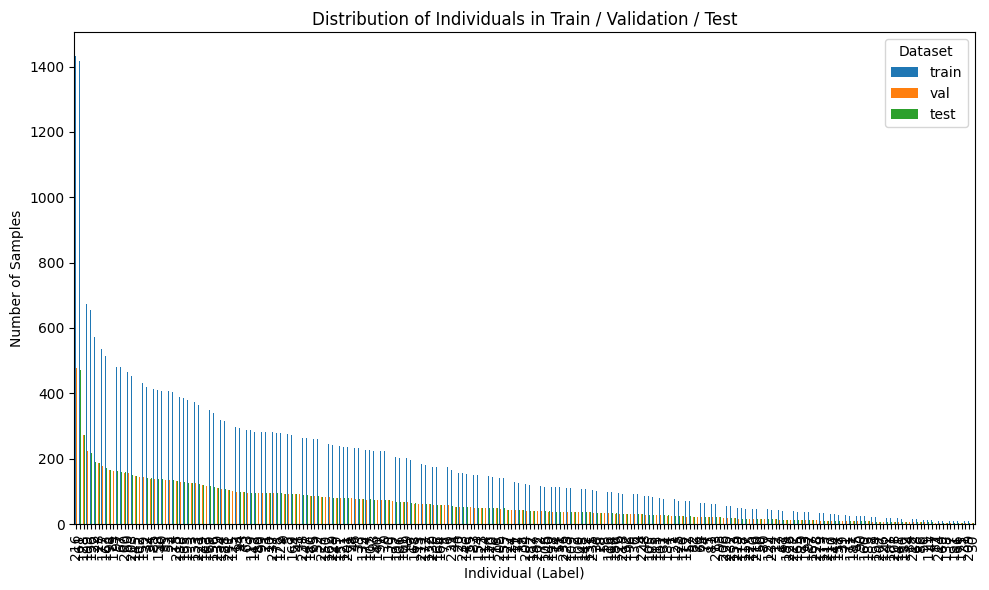

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# --- Count labels in each split ---
def count_labels(dataset):
    """Count label frequencies in a PyTorch dataset."""
    return Counter(label.item() for _, label in dataset)

datasets = {
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
}

# Create DataFrame with counts
counts_df = pd.DataFrame({
    split: pd.Series(count_labels(ds))
    for split, ds in datasets.items()
}).fillna(0).astype(int)

# --- Sort by frequency in train ---
counts_df = counts_df.sort_values(by="train", ascending=False)

# --- Compute totals (not for plotting) ---
total_per_individual = counts_df.sum(axis=1)

# --- Metrics ---
total_vocalizations = int(total_per_individual.sum())
max_vocalizations   = int(total_per_individual.max())
min_vocalizations   = int(total_per_individual.min())
mean_vocalizations  = float(total_per_individual.mean())
std_vocalizations   = float(total_per_individual.std(ddof=1))  # sample SD

# --- Display counts DataFrame ---
display(counts_df)

# --- Print requested metrics ---
print("=== Dataset metrics (all splits combined) ===")
print(f"Total vocalizations: {total_vocalizations}")
print(f"Maximum vocalizations per individual: {max_vocalizations}")
print(f"Minimum vocalizations per individual: {min_vocalizations}")
print(f"Vocalizations per individual (mean ± SD): {mean_vocalizations:.1f} ± {std_vocalizations:.1f}")
print(f"Vocalizations per individual (mean ± SD, rounded): {round(mean_vocalizations):.0f} ± {round(std_vocalizations):.0f}")

# --- Plot per-split distribution ---
counts_df.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Individual (Label)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Individuals in Train / Validation / Test')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


## Lightning DataModule with Custom Collate (variable-length sequences)

In [15]:
from lightning import LightningDataModule
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import os

# --- Collate: pad variable-length sequences and return lengths ---
def custom_collate_fn(batch):
    sequences, labels = zip(*batch)  # sequences: [Tensor(n_i, d)], labels: [Tensor(,)]
    # Make sure types are consistent
    sequences = [seq.to(dtype=torch.float32) for seq in sequences]
    labels = torch.stack([lab.to(dtype=torch.long) for lab in labels])

    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    # Pad to (B, T_max, D); default padding_value=0.0 is explicit here
    padded_sequences = nn.utils.rnn.pad_sequence(
        sequences, batch_first=True, padding_value=0.0
    )
    return padded_sequences, lengths, labels


class BirdsongDataModule(LightningDataModule):
    def __init__(
        self,
        train_dataset,
        val_dataset,
        test_dataset,
        batch_size: int = 32,
        num_workers: int = 0,              # 0 is safest in notebooks
        pin_memory: bool = False,          # set True if training on GPU
        persistent_workers: bool = False,  # True only if num_workers > 0
        drop_last: bool = False,           # set True if you need fixed batch shapes
    ):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset

        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        self.persistent_workers = persistent_workers if num_workers > 0 else False
        self.drop_last = drop_last

    def _make_loader(self, dataset, shuffle: bool):
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=custom_collate_fn,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers,
            drop_last=self.drop_last,
        )

    def train_dataloader(self):
        return self._make_loader(self.train_dataset, shuffle=True)

    def val_dataloader(self):
        return self._make_loader(self.val_dataset, shuffle=False)

    def test_dataloader(self):
        return self._make_loader(self.test_dataset, shuffle=False)


# Example instantiation (tweak workers/pin_memory depending on your setup)
use_cuda = torch.cuda.is_available()
data_module = BirdsongDataModule(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32,
    num_workers=3,               # try >0 outside notebooks if IO becomes a bottleneck
    pin_memory=use_cuda,         # helpful when using CUDA
    persistent_workers=True,    # set True only if num_workers > 0
    drop_last=False,
)


## LSTM-based Birdsong Classifier LightningModule

In [16]:
import torch
from torch import nn
import torch.nn.functional as F
from lightning import LightningModule
import torchmetrics
from torchmetrics.classification import F1Score
import logging
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


class BirdsongClassifier(LightningModule):
    def __init__(
        self,
        embedding_dim: int,
        hidden_dim: int,
        num_classes: int,
        lr: float = 1e-3,
        bidirectional: bool = False,
        dropout: float = 0.0,
        use_mean_pool: bool = False,
        class_weights: torch.Tensor | None = None,  # pass on correct device later in setup()
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])
        self.class_weights = class_weights  # store raw; move to device in setup()

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if 1 < 1 else 0.0,  # dropout between layers if num_layers>1 (kept 1 layer here)
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, num_classes),
        )

        # Metrics (Lightning will aggregate over epoch)
        self.train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy   = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_f1         = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.test_f1        = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro")

        # Loss (class weights optional; moved to device in setup())
        self.criterion = nn.CrossEntropyLoss(weight=None)

        self.use_mean_pool = use_mean_pool

    def setup(self, stage=None):
        # Move class weights to the right device if provided
        if self.class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D), lengths: (B,)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)

        if self.use_mean_pool:
            # Mean over valid timesteps (mask-aware)
            out, lens = pad_packed_sequence(packed_out, batch_first=True)  # (B, T_max, H[*2])
            lens = lens.to(out.device).clamp_min(1).unsqueeze(1)           # (B, 1)
            feats = out.sum(dim=1) / lens                                  # (B, H[*2])
        else:
            # Last hidden state from the top layer
            # h_n shape: (num_layers * num_directions, B, H)
            feats = h_n[-1]                                                # (B, H[*2] if bidirectional)

        logits = self.fc(feats)  # (B, C)
        return logits

    def training_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        acc = self.train_accuracy(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc",  acc,  prog_bar=True)
        logger.info(f"Batch {batch_idx} - Train Loss: {loss.item():.4f} - Train Acc: {acc:.4f}")
        return loss

    def validation_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        acc = self.val_accuracy(logits, y)
        f1  = self.val_f1(logits, y)
        
        # update metrics' internal state
        # self.val_accuracy.update(logits, y)
        # self.val_f1.update(logits, y)

        # self.log("val_loss", loss, prog_bar=True)
        # self.log("val_acc",  acc,  prog_bar=True)
        # self.log("val_f1",   f1,   prog_bar=True)
         # log epoch-level values
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc",  acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_f1",   f1,  prog_bar=True, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        acc = self.test_accuracy(logits, y)
        f1 = self.test_f1(logits, y)

        # self.test_accuracy.update(logits, y)
        # self.log("test_loss", loss, prog_bar=True)
        # self.log("test_acc",  acc,  prog_bar=True)
        self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_acc",  acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_f1", f1, prog_bar=True, on_step=False, on_epoch=True)
        logger.info(f"Batch {batch_idx} - Test Loss: {loss.item():.4f} - Test Acc: {acc:.4f}")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [17]:


all_labels = (
    list(id_train_dict.values()) +
    list(id_val_dict.values()) +
    list(id_test_dict.values())
)

model = BirdsongClassifier(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=len(set(all_labels)),  # Adjusted based on label encoder
    lr=LEARNING_RATE
)


## Define Callbacks for Model Checkpointing and Early Stopping

In [18]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model (by val_f1) and also keep the last checkpoint
checkpoint_callback = ModelCheckpoint(
    monitor="val_f1",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename=f"best-{DATASET_NAME}-{SPLIT_TYPE}-{EXPERIMENT_TAG}-{{epoch:02d}}-{{val_f1:.4f}}"
    # auto_insert_metric_name=False,  # uncomment if you don't want Lightning to append metric names
)

# Early stopping if validation doesn't improve
early_stop_callback = EarlyStopping(
    monitor="val_f1",
    mode="max",
    patience=10,
    min_delta=1e-4,
)


## Trainer configuration with TensorBoard and CSV loggers

In [19]:
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger

# TensorBoard + CSV under: logs/<DATASET_NAME>/<SPLIT_TYPE>/<RUN_NAME>/version_x/
tb_logger = TensorBoardLogger(
    save_dir=str(LOG_DIR),   # logs/<DATASET_NAME>/<SPLIT_TYPE>
    name=RUN_NAME,           # <DATASET_NAME>_<SPLIT_TYPE>_RNN
)

csv_logger = CSVLogger(
    save_dir=str(LOG_DIR),   # same root, same run name
    name=RUN_NAME,
)

trainer = Trainer(
    max_epochs=40,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=[tb_logger, csv_logger],
    log_every_n_steps=10,
    # Reproducibility and stability (safe defaults)
    deterministic=True,        # ensures repeatable results (may be slightly slower)
    gradient_clip_val=1.0,     # helps stabilize RNN training
    # num_sanity_val_steps=0,  # uncomment if your val metrics require skipping sanity checks
    # precision="16-mixed",    # optional: speed-up on GPU; leave commented to keep numerics identical
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Train the model

In [ ]:
trainer.fit(model, datamodule=data_module)


2026-04-21 02:36:26.181049: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 02:36:26.236865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776738986.261996   23303 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776738986.268690   23303 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-21 02:36:26.307308: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Plot training and validation metrics from CSV logs

Reading metrics from: /teamspace/studios/this_studio/logs/greatTit/acrossyear/greatTit_acrossyear_birdnet_lstm_ordered_random_seeded/version_3/metrics.csv


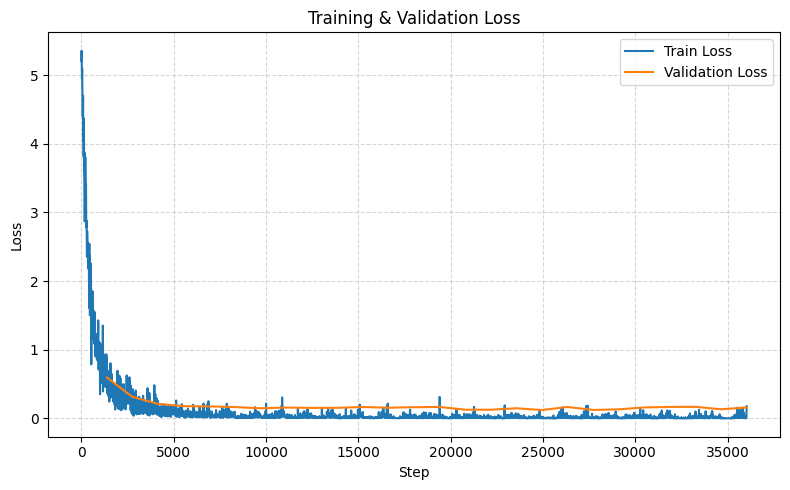

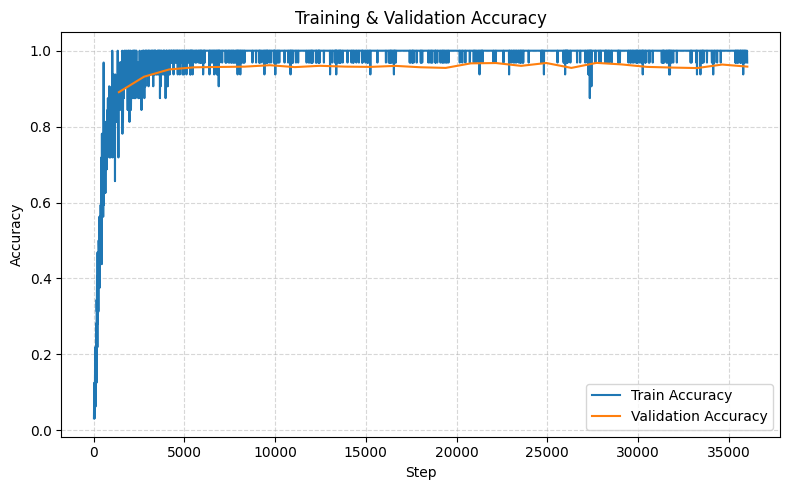

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the latest version directory created by the loggers
run_dir = LOG_DIR / RUN_NAME
version_dirs = sorted([p for p in run_dir.glob("version_*") if p.is_dir()],
                      key=lambda p: int(p.name.split("_")[-1]))
if not version_dirs:
    raise FileNotFoundError(f"No version_* folders found under {run_dir}")
latest = version_dirs[-1]
metrics_csv = latest / "metrics.csv"
print("Reading metrics from:", metrics_csv)

df = pd.read_csv(metrics_csv)

# Helper: pick the x-axis. Prefer 'step' if present, else 'epoch' (falls back to index).
x = df["step"] if "step" in df.columns else (df["epoch"] if "epoch" in df.columns else df.index)

# Filter rows that actually contain each metric
df_train_loss = df[df["train_loss"].notna()] if "train_loss" in df.columns else pd.DataFrame()
df_val_loss   = df[df["val_loss"].notna()]   if "val_loss"   in df.columns else pd.DataFrame()
df_train_acc  = df[df["train_acc"].notna()]  if "train_acc"  in df.columns else pd.DataFrame()
df_val_acc    = df[df["val_acc"].notna()]    if "val_acc"    in df.columns else pd.DataFrame()

# ---- Plot 1: Train vs Validation Loss ----
plt.figure(figsize=(8, 5))
if not df_train_loss.empty:
    plt.plot(df_train_loss["step"] if "step" in df_train_loss else df_train_loss.index,
             df_train_loss["train_loss"], label="Train Loss")
if not df_val_loss.empty:
    plt.plot(df_val_loss["step"] if "step" in df_val_loss else df_val_loss.index,
             df_val_loss["val_loss"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Plot 2: Train vs Validation Accuracy ----
plt.figure(figsize=(8, 5))
if not df_train_acc.empty:
    plt.plot(df_train_acc["step"] if "step" in df_train_acc else df_train_acc.index,
             df_train_acc["train_acc"], label="Train Accuracy")
if not df_val_acc.empty:
    plt.plot(df_val_acc["step"] if "step" in df_val_acc else df_val_acc.index,
             df_val_acc["val_acc"], label="Validation Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Test the final (non-checkpoint) model on the test dataset

In [ ]:

trainer.test(model, datamodule=data_module)

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9578106999397278     │
│          test_f1          │    0.6815313100814819     │
│         test_loss         │    0.15236526727676392    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.15236526727676392,
  'test_acc': 0.9578106999397278,
  'test_f1': 0.6815313100814819}]

## Load the best checkpoint and evaluate it on the test set

In [ ]:
# Load the best model (optional)
best_model_path = checkpoint_callback.best_model_path
print(f"Best model saved at: {best_model_path}")

# Alternative: load a specific checkpoint manually
# best_model_path = "KiWi_logs/individual_identification/version_3/checkpoints/best-individual-identification-KiWi.ckpt"

best_model = BirdsongClassifier.load_from_checkpoint(best_model_path)
best_model.eval()
# Evaluate the best model on the test set
results = trainer.test(best_model, datamodule=data_module)

# Print all metrics in a nice format
print("\nTest Metrics:")
for metric, value in results[0].items():
    print(f"{metric}: {value:.4f} ({value*100:.1f}%)" if "acc" in metric or "f1" in metric else f"{metric}: {value:.4f}")

test_acc = results[0]['test_acc']   # lo multiplicas por 100 para tenerlo en porcentaje


Best model saved at: /teamspace/studios/this_studio/logs/greatTit/acrossyear/greatTit_acrossyear_birdnet_lstm_ordered_random_seeded/version_2/checkpoints/best-greatTit-acrossyear-birdnet_lstm_ordered_random_seeded-epoch=15-val_f1=0.7522.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9669327139854431     │
│          test_f1          │    0.7477838397026062     │
│         test_loss         │    0.12327562272548676    │
└───────────────────────────┴───────────────────────────┘


Test Metrics:
test_loss: 0.1233
test_acc: 0.9669 (96.7%)
test_f1: 0.7478 (74.8%)


## CMC@1 and mAP@5

In [24]:
import numpy as np
import torch
from sklearn.metrics import classification_report

@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for x, lengths, y in loader:
        x = x.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        logits = model(x, lengths)          # (B, C)
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    logits = torch.cat(all_logits, dim=0)   # (N, C)
    labels = torch.cat(all_labels, dim=0)   # (N,)
    return logits, labels


def cmc1_map5_from_logits(logits: torch.Tensor, labels: torch.Tensor, k: int = 5):
    """
    Compute CMC@1 and mAP@k from class-score logits.

    Assumes a closed-set classification setting where each query has exactly one
    relevant class (its true label).
    """
    n_classes = logits.shape[1]
    k = min(k, n_classes)

    topk = torch.topk(logits, k=k, dim=1).indices  # (N, k)

    # CMC@1 = top-1 accuracy in the ranked list
    cmc1 = (topk[:, 0] == labels).float().mean().item()

    # mAP@k for the single-relevant-label case
    matches = (topk == labels.unsqueeze(1))        # (N, k)
    ap = torch.zeros(labels.size(0), dtype=torch.float32)

    hit_idx = matches.nonzero(as_tuple=False)      # rows: [query_index, rank_index]
    if hit_idx.numel() > 0:
        first_hit = {}
        for i, r in hit_idx.tolist():
            if i not in first_hit:
                first_hit[i] = r
        for i, r in first_hit.items():
            ap[i] = 1.0 / (r + 1)                  # rank is 1-based

    mapk = ap.mean().item()
    return cmc1, mapk


In [25]:
# ---- Run evaluation on best checkpoint ----
best_model = BirdsongClassifier.load_from_checkpoint(best_model_path)
best_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

test_loader = data_module.test_dataloader()

logits, y_true_t = collect_logits_and_labels(best_model, test_loader, device)

# Classification report
y_pred_t = torch.argmax(logits, dim=1)
y_true = y_true_t.numpy()
y_pred = y_pred_t.numpy()

labels_idx = list(range(len(le.classes_)))
target_names = [str(c) for c in le.classes_]

report_text = classification_report(
    y_true,
    y_pred,
    labels=labels_idx,
    target_names=target_names,
    digits=4,
    zero_division=0,
)
print(report_text)

# Save TXT report
CLASS_REPORT_TXT_FILE.parent.mkdir(parents=True, exist_ok=True)
CLASS_REPORT_TXT_FILE.write_text(report_text)
print(f"\nSaved classification report (txt) to: {CLASS_REPORT_TXT_FILE}")

# Save CSV report
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels_idx,
    target_names=target_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).transpose()

# Keep only per-class rows
per_class_report_df = report_df.loc[target_names].reset_index()
per_class_report_df = per_class_report_df.rename(columns={"index": "individual"})

per_class_report_df.to_csv(CLASS_REPORT_CSV_FILE, index=False)
print(f"Saved classification report (csv) to: {CLASS_REPORT_CSV_FILE}")

display(per_class_report_df.head())

# CMC@1 and mAP@5
cmc1, map5 = cmc1_map5_from_logits(logits, y_true_t, k=5)
print(f"CMC@1 (from logits): {cmc1:.4f}")
print(f"mAP@5 (from logits): {map5:.4f}")

              precision    recall  f1-score   support

     pf71344     0.9733    0.9733    0.9733        75
     pf71356     0.9600    0.9231    0.9412        26
     pf71360     1.0000    1.0000    1.0000        37
     pf71373     0.9837    0.9603    0.9719       126
     pf71378     1.0000    0.9032    0.9492        31
     pf71395     0.9780    0.9674    0.9727        92
     pf71411     0.9828    0.9828    0.9828        58
     pf71419     1.0000    0.7500    0.8571         4
     pf71436     0.8889    1.0000    0.9412         8
     pf71904     1.0000    0.9892    0.9946        93
     pf71915     0.9894    0.9789    0.9841        95
     pf71937     0.9500    0.8837    0.9157        43
     pf72048     1.0000    0.9333    0.9655        15
     pf72101     0.7805    0.9697    0.8649        99
     pf72109     0.8750    0.9211    0.8974        38
     pf72115     1.0000    0.8636    0.9268        22
     pf72140     1.0000    0.9583    0.9787        48
     pf72172     1.0000    

,individual,precision,recall,f1-score,support
0,pf71344,0.973333,0.973333,0.973333,75.0
1,pf71356,0.960000,0.923077,0.941176,26.0
2,pf71360,1.000000,1.000000,1.000000,37.0
3,pf71373,0.983740,0.960317,0.971888,126.0
4,pf71378,1.000000,0.903226,0.949153,31.0


CMC@1 (from logits): 0.9669
mAP@5 (from logits): 0.9789


## Model evaluation function with metrics and ROC AUC

In [26]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, balanced_accuracy_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_split(model, loader, le, split_name: str):
    """Evaluate a model on a dataloader and compute multiple metrics."""
    model.eval()
    device = next(model.parameters()).device

    all_preds, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(device)
            lengths = lengths.to(device)
            y = y.to(device)

            logits = model(x, lengths)
            preds = torch.argmax(logits, dim=1)

            all_logits.append(logits.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    # Arrays
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    logits_np = np.concatenate(all_logits, axis=0)

    # Confusion matrix (plot)
    labels = list(range(len(le.classes_)))
    # cm = confusion_matrix(y_true, y_pred, labels=labels)
    # fig, ax = plt.subplots(figsize=(8, 6))
    # ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
    #     ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True
    # )
    # ax.set_title(f"Confusion Matrix — {split_name}")
    # plt.tight_layout()
    # plt.show()

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    acc_bal = balanced_accuracy_score(y_true, y_pred)
    recall_macro    = recall_score(y_true, y_pred, labels=labels, average="macro",    zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    f1_macro        = f1_score(y_true, y_pred,     labels=labels, average="macro",    zero_division=0)
    f1_weighted     = f1_score(y_true, y_pred,     labels=labels, average="weighted", zero_division=0)

    # ROC AUC (macro)
    num_classes = len(np.unique(y_true))
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    probs = torch.softmax(torch.tensor(logits_np), dim=1).numpy()
    roc_auc_macro = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")

    # Print and return
    print(f"{split_name} — Accuracy:          {acc:.4f} ({acc*100:.1f}%)")
    print(f"{split_name} — Balanced accuracy: {acc_bal:.4f} ({acc_bal*100:.1f}%)")
    print(f"{split_name} — Recall (macro):    {recall_macro:.4f}")
    print(f"{split_name} — Recall (weighted): {recall_weighted:.4f}")
    print(f"{split_name} — F1 (macro):        {f1_macro:.4f} ({f1_macro*100:.1f}%)")
    print(f"{split_name} — F1 (weighted):     {f1_weighted:.4f}")
    print(f"{split_name} — ROC AUC (macro):   {roc_auc_macro:.4f}\n")

    return {
        "accuracy": acc,
        "balanced_accuracy": acc_bal,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro,
    }



## Evaluate best model on Validation and Test sets, then plot Test metrics as a bubble chart

In [ ]:
# Ensure the model is on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

# Evaluate and collect metrics
val_metrics  = evaluate_split(best_model, data_module.val_dataloader(),  le, "Validation")
test_metrics = evaluate_split(best_model, data_module.test_dataloader(), le, "Test")


Validation — Accuracy:          0.9675 (96.8%)
Validation — Balanced accuracy: 0.9284 (92.8%)
Validation — Recall (macro):    0.9284
Validation — Recall (weighted): 0.9675
Validation — F1 (macro):        0.9377 (93.8%)
Validation — F1 (weighted):     0.9669
Validation — ROC AUC (macro):   0.9998

Test — Accuracy:          0.9669 (96.7%)
Test — Balanced accuracy: 0.9292 (92.9%)
Test — Recall (macro):    0.9292
Test — Recall (weighted): 0.9669
Test — F1 (macro):        0.9352 (93.5%)
Test — F1 (weighted):     0.9661
Test — ROC AUC (macro):   0.9998



## 20) Saving metrics

In [ ]:
summary_row = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "dataset_name": DATASET_NAME,
    "split_type": SPLIT_TYPE,
    "split_mode": SPLIT_MODE,
    "sequence_mode": SEQUENCE,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "learning_rate": LEARNING_RATE,

    "val_accuracy": val_metrics["accuracy"],
    "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    "val_recall_macro": val_metrics["recall_macro"],
    "val_recall_weighted": val_metrics["recall_weighted"],
    "val_f1_macro": val_metrics["f1_macro"],
    "val_f1_weighted": val_metrics["f1_weighted"],
    "val_roc_auc_macro": val_metrics["roc_auc_macro"],

    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_recall_macro": test_metrics["recall_macro"],
    "test_recall_weighted": test_metrics["recall_weighted"],
    "test_f1_macro": test_metrics["f1_macro"],
    "test_f1_weighted": test_metrics["f1_weighted"],
    "test_roc_auc_macro": test_metrics["roc_auc_macro"],

    # Great tit ranking metrics
    "test_cmc1": cmc1,
    "test_map5": map5,
}

new_row_df = pd.DataFrame([summary_row])

key_cols = ["run_name", "seed"]

if METRICS_FILE.exists():
    metrics_df = pd.read_csv(METRICS_FILE)

    missing_cols = [c for c in key_cols if c not in metrics_df.columns]
    if missing_cols:
        raise ValueError(
            f"Missing key columns in existing metrics file: {missing_cols}"
        )

    mask = pd.Series(True, index=metrics_df.index)
    for col in key_cols:
        mask &= metrics_df[col] == summary_row[col]

    if mask.any():
        metrics_df = metrics_df.loc[~mask].copy()
        action = "updated"
    else:
        action = "appended"

    metrics_df = pd.concat([metrics_df, new_row_df], ignore_index=True)

else:
    metrics_df = new_row_df.copy()
    action = "created"

metrics_df = metrics_df.sort_values(by=key_cols).reset_index(drop=True)
metrics_df.to_csv(METRICS_FILE, index=False)

print(f"Metrics file {action}: {METRICS_FILE}")
display(metrics_df)

Metrics file appended: /teamspace/studios/this_studio/Results/greatTit/acrossyear/Metrics/greatTit_acrossyear_birdnet_lstm_ordered_random_seeded_final_metrics.csv


,run_name,seed,dataset_name,split_type,split_mode,sequence_mode,embedding_dim,hidden_dim,learning_rate,val_accuracy,...,val_roc_auc_macro,test_accuracy,test_balanced_accuracy,test_recall_macro,test_recall_weighted,test_f1_macro,test_f1_weighted,test_roc_auc_macro,test_cmc1,test_map5
0,greatTit_acrossyear_birdnet_lstm_ordered_rando...,18,greatTit,acrossyear,random_seeded,ordered,1024,256,0.001,0.970157,...,0.999853,0.970085,0.937444,0.937444,0.970085,0.946053,0.969705,0.999837,0.970085,0.980355
1,greatTit_acrossyear_birdnet_lstm_ordered_rando...,23,greatTit,acrossyear,random_seeded,ordered,1024,256,0.001,0.967524,...,0.999817,0.966933,0.929224,0.929224,0.966933,0.935204,0.966101,0.999783,0.966933,0.978870


In [29]:
# ------------------------------------------------------------------
# Aggregate summary over all seeds currently stored in METRICS_FILE
# ------------------------------------------------------------------
metrics_df = pd.read_csv(METRICS_FILE)

# Metrics that must exist
required_metric_cols = ["test_accuracy", "test_f1_macro", "test_roc_auc_macro"]
missing_metric_cols = [c for c in required_metric_cols if c not in metrics_df.columns]
if missing_metric_cols:
    raise ValueError(f"Missing metric columns in metrics file: {missing_metric_cols}")

# Base summary
aggregate_summary = {
    "dataset_name": metrics_df["dataset_name"].iloc[0],
    "split_type": metrics_df["split_type"].iloc[0],
    "split_mode": metrics_df["split_mode"].iloc[0] if "split_mode" in metrics_df.columns else "N/A",
    "sequence_mode": metrics_df["sequence_mode"].iloc[0],
    "embedding_dim": metrics_df["embedding_dim"].iloc[0],
    "n_seeds": metrics_df["seed"].nunique(),

    "test_accuracy": f"{metrics_df['test_accuracy'].mean():.3f} ± {metrics_df['test_accuracy'].std(ddof=1):.3f}",
    "test_f1_macro": f"{metrics_df['test_f1_macro'].mean():.3f} ± {metrics_df['test_f1_macro'].std(ddof=1):.3f}",
    "test_roc_auc_macro": f"{metrics_df['test_roc_auc_macro'].mean():.4f} ± {metrics_df['test_roc_auc_macro'].std(ddof=1):.4f}",
}

# Optional ranking metrics for great tit
if "test_cmc1" in metrics_df.columns:
    aggregate_summary["test_cmc1"] = (
        f"{metrics_df['test_cmc1'].mean():.4f} ± {metrics_df['test_cmc1'].std(ddof=1):.4f}"
    )

if "test_map5" in metrics_df.columns:
    aggregate_summary["test_map5"] = (
        f"{metrics_df['test_map5'].mean():.4f} ± {metrics_df['test_map5'].std(ddof=1):.4f}"
    )

aggregate_summary_df = pd.DataFrame([aggregate_summary])

print("\nAggregate summary across seeds:")
display(aggregate_summary_df)


Aggregate summary across seeds:


,dataset_name,split_type,split_mode,sequence_mode,embedding_dim,n_seeds,test_accuracy,test_f1_macro,test_roc_auc_macro,test_cmc1,test_map5
0,greatTit,acrossyear,random_seeded,ordered,1024,2,0.969 ± 0.002,0.941 ± 0.008,0.9998 ± 0.0000,0.9685 ± 0.0022,0.9796 ± 0.0011


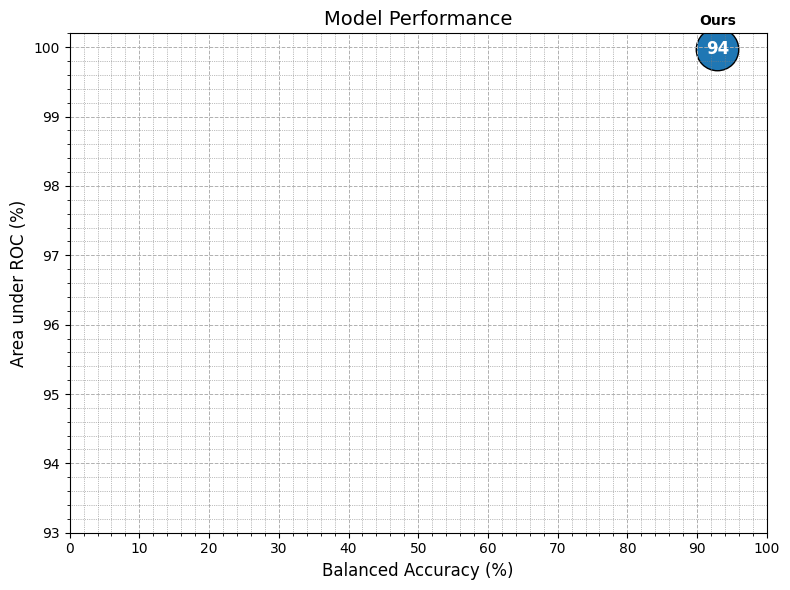

In [ ]:

# --- Bubble plot from TEST metrics ---
import matplotlib.pyplot as plt
import numpy as np

# Metrics for the figure
balanced_accuracy = test_metrics["balanced_accuracy"] * 100   # Balanced Accuracy (%)
roc_auc = test_metrics["roc_auc_macro"] * 100            # Area under ROC (%)
f1_macro = test_metrics["f1_macro"]                       # 0..1
model_name = "Ours"

# Figure
fig, ax = plt.subplots(figsize=(8, 6))

# Bubble size proportional to F1 (tune the factor if needed)
bubble_size = 1000 * f1_macro

# Scatter
ax.scatter(balanced_accuracy, roc_auc, s=bubble_size, edgecolors='black', alpha=1)

# Text inside bubble: F1 in percent, rounded
ax.text(balanced_accuracy, roc_auc, f"{int(round(f1_macro*100))}",
        fontsize=12, ha='center', va='center', color='white', fontweight='bold')

# Model name above bubble
ax.text(balanced_accuracy, roc_auc + 0.3, model_name,
        fontsize=10, ha='center', va='bottom', color='black', fontweight='bold')

# Axes customization (adjust if your ranges differ)
ax.set_xlim(0, 100)
ax.set_ylim(93, 100.2)

ax.set_xticks(np.arange(0, 101, 10))
ax.set_yticks(np.arange(93, 100.2, 1))
ax.set_xticks(np.arange(0, 101, 2), minor=True)
ax.set_yticks(np.arange(93, 100.2, 0.2), minor=True)

ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
ax.grid(True, which='major', linestyle='--', linewidth=0.7)

ax.set_xlabel("Balanced Accuracy (%)", fontsize=12)
ax.set_ylabel("Area under ROC (%)", fontsize=12)
ax.set_title("Model Performance", fontsize=14)

plt.tight_layout()
plt.savefig("LSTM_AudioID_performance.png", dpi=300)
plt.show()
